In [1]:
import os
import tempfile
import scanpy as sc
import gc
import anndata
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scvi
import seaborn as sns
import torch

/software/cellgen/team361/am74/envs/pertpy-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path = "/nfs/team361/dj17/MintFlow_2025/xenium_RCC/annotated_data/"
files = [os.path.join(path, f) for f in os.listdir(path) if f.endswith(".h5ad")]
adatas = []
for f in files:
    ad = sc.read(f)     
    gc.collect()        
adata_merged = sc.concat(adatas, join="outer", label="batch", keys=files)

/software/cellgen/team361/am74/envs/pertpy-env/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team361/am74/envs/pertpy-env/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [3]:
path = "/nfs/team361/dj17/MintFlow_2025/xenium_RCC/unannotated_data/"
files = [os.path.join(path, f) for f in os.listdir(path) if f.endswith(".h5ad")]
adatas = []
for f in files:
    ad = sc.read(f)    
    adatas.append(ad)   
    gc.collect()       
adata_merged_unannot = sc.concat(adatas, join="outer", label="batch", keys=files)

/software/cellgen/team361/am74/envs/pertpy-env/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [4]:
adata_merged_unannot.obs['batch'].value_counts()

batch
/nfs/team361/dj17/MintFlow_2025/xenium_RCC/unannotated_data/CV4-KID-0-FO-1.h5ad       121108
/nfs/team361/dj17/MintFlow_2025/xenium_RCC/unannotated_data/CV8-KID-0-FO-1.h5ad       110526
/nfs/team361/dj17/MintFlow_2025/xenium_RCC/unannotated_data/CV7-KID-0-FO-1.h5ad       109349
/nfs/team361/dj17/MintFlow_2025/xenium_RCC/unannotated_data/CV7-KID-0-FT-1-s3.h5ad     84449
/nfs/team361/dj17/MintFlow_2025/xenium_RCC/unannotated_data/CV8-KID-0-FT-1-s3.h5ad     76886
/nfs/team361/dj17/MintFlow_2025/xenium_RCC/unannotated_data/CV7-KID-0-FT-3-S3.h5ad     75823
/nfs/team361/dj17/MintFlow_2025/xenium_RCC/unannotated_data/CV5-KID-0-FO-1.h5ad        73595
/nfs/team361/dj17/MintFlow_2025/xenium_RCC/unannotated_data/CV7-KID-0-FT-4-S3.h5ad     53108
/nfs/team361/dj17/MintFlow_2025/xenium_RCC/unannotated_data/CV5-KID-0-FT-1-s3.h5ad     43921
/nfs/team361/dj17/MintFlow_2025/xenium_RCC/unannotated_data/CV3-KID-0-FT-3-s3.h5ad     41278
/nfs/team361/dj17/MintFlow_2025/xenium_RCC/unannotated_data/CV5-

In [5]:
adata_merged_unannot.layers['counts']=adata_merged_unannot.X.copy()

In [6]:
adata_merged.obs['cell_status']='annoteted'
adata_merged_unannot.obs['cell_status']='unannoteted'


In [7]:
adata_merged.X = adata_merged.layers['counts'].copy()

In [8]:
full_data = adata_merged.concatenate(adata_merged_unannot)

/tmp/ipykernel_3948855/1508973173.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  full_data = adata_merged.concatenate(adata_merged_unannot)
/software/cellgen/team361/am74/envs/pertpy-env/lib/python3.10/site-packages/anndata/_core/merge.py:1434: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  warn(
/software/cellgen/team361/am74/envs/pertpy-env/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team361/am74/envs/pertpy-env/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.war

In [9]:
gc.collect()

10

In [10]:
scvi.model.SCVI.setup_anndata(
    full_data,
    layer="counts",
    batch_key="batch")

In [11]:
scvi_model = scvi.model.SCVI(full_data, n_layers=2, n_latent=30)

In [12]:
scvi_model.train()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/software/cellgen/team361/am74/envs/pertpy-env/lib/python3.10/site-packages/torch/__init__.py:1551: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  return _C._get_float32_matmul_precision()
You are using a CUDA device ('NVIDIA A100-SXM4-80GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision

Epoch 3/3: 100%|█| 3/3 [08:24<00:00, 167.16s/it, v_num=1, train_loss_step=1.45e+

`Trainer.fit` stopped: `max_epochs=3` reached.


Epoch 3/3: 100%|█| 3/3 [08:24<00:00, 168.15s/it, v_num=1, train_loss_step=1.45e+


In [13]:
SCVI_LATENT_KEY = "X_scVI_full_data"
full_data.obsm[SCVI_LATENT_KEY] = scvi_model.get_latent_representation()

In [14]:
SCANVI_CELLTYPE_KEY = "celltype_scanvi"

full_data.obs[SCANVI_CELLTYPE_KEY] = "Unknown"
ss2_mask = full_data.obs["cell_status"] == "annoteted"
full_data.obs[SCANVI_CELLTYPE_KEY][ss2_mask] = full_data.obs.level_3_cell_type[ss2_mask].values

/tmp/ipykernel_3948855/3345132542.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  full_data.obs[SCANVI_CELLTYPE_KEY][ss2_mask] = full_data.obs.level_3_cell_type[ss2_mask].values
/tmp/ipykernel_3948855/3345132542.py:5: SettingWithCopyWarn

In [15]:
np.unique(full_data.obs[SCANVI_CELLTYPE_KEY], return_counts=True)

(array(['Activated endothelium', 'B lymphocyte', 'CD4+ T lymphocyte',
        'CD8+ T lymphocyte', 'Cancer associated fibroblast',
        'Conventional dendritic cell', 'DN T lymphocyte', 'Distal tubule',
        'Glomerular capillary', 'Juxtaglomerular cell',
        'Kidney resident macrophage', 'Lymphatic vasculature',
        'Mixed tubular', 'Pericyte', 'Peritubular capillary',
        'Plasma cell', 'Podocyte', 'Proximal tubule',
        'Resident fibroblast', 'Tumour associated macrophage',
        'Tumour capillary vasculature', 'Tumour epithelium', 'Unknown',
        'Vascular smooth muscle'], dtype=object),
 array([  26978,    6820,   54136,  153669,   71574,    4674,   10740,
         106737,   15647,    4756,   11996,   10096,   35567,   33577,
          41708,   18659,   18745,   81468,   73128,  292724,  106704,
         816906, 1076404,   19266]))

In [16]:
scanvi_model = scvi.model.SCANVI.from_scvi_model(
    scvi_model,
    adata=full_data,
    unlabeled_category="unannoteted",
    labels_key=SCANVI_CELLTYPE_KEY,
)

In [17]:
scanvi_model.train(max_epochs=20, n_samples_per_label=100)

INFO     Training for 20 epochs.                                                                                   


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/software/cellgen/team361/am74/envs/pertpy-env/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=59` in the `DataLoader` to improve performance.


Epoch 20/20: 100%|███████████████████████████| 20/20 [1:57:12<00:00, 353.73s/it, v_num=1, train_loss_step=1.61e+3, train_loss_epoch=1.4e+3]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 20/20: 100%|███████████████████████████| 20/20 [1:57:12<00:00, 351.62s/it, v_num=1, train_loss_step=1.61e+3, train_loss_epoch=1.4e+3]


In [19]:
SCANVI_LATENT_KEY = "X_scANVI"
SCANVI_PREDICTION_KEY = "C_scANVI"

full_data.obsm[SCANVI_LATENT_KEY] = scanvi_model.get_latent_representation(full_data)
full_data.obs[SCANVI_PREDICTION_KEY] = scanvi_model.predict(full_data)

In [20]:
# in order to make colors matchup
full_data.obs.C_scANVI = pd.Categorical(
    full_data.obs.C_scANVI.values, categories=full_data.obs.level_3_cell_type.cat.categories
)

In [21]:
df = full_data.obs.groupby(["level_3_cell_type", SCANVI_PREDICTION_KEY]).size().unstack(fill_value=0)

/tmp/ipykernel_3948855/972186867.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = full_data.obs.groupby(["level_3_cell_type", SCANVI_PREDICTION_KEY]).size().unstack(fill_value=0)


In [22]:
conf_mat = df / df.sum(axis=1).values[:, np.newaxis]

Text(0, 0.5, 'Observed')

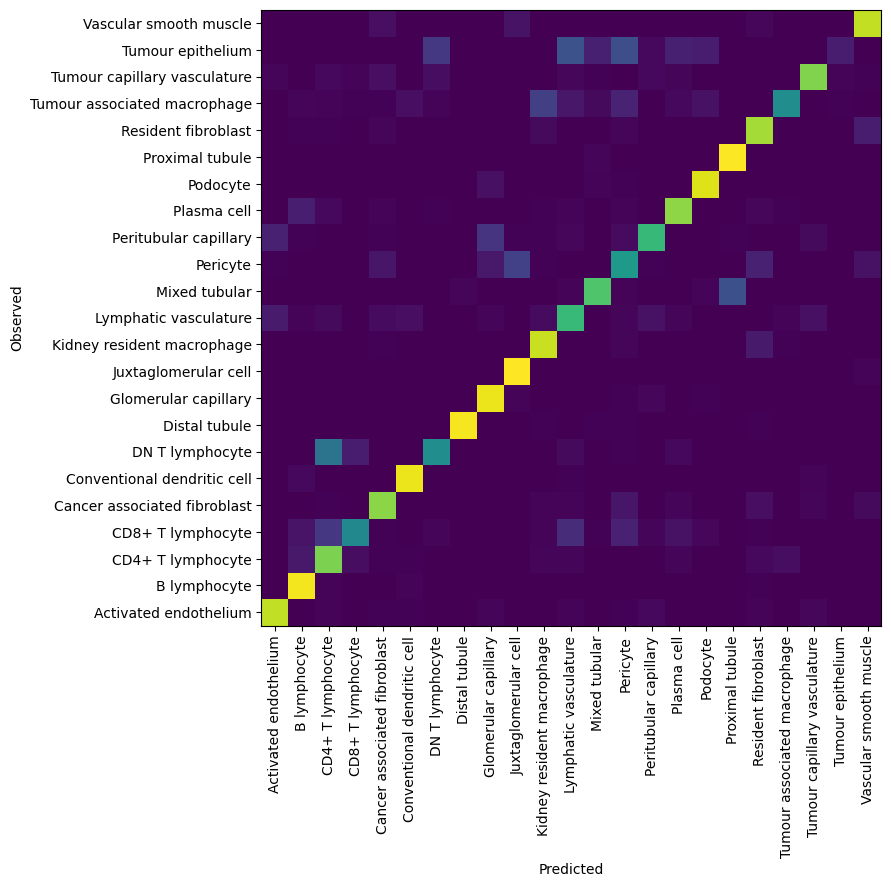

In [23]:
plt.figure(figsize=(8, 8))
_ = plt.pcolor(conf_mat)
_ = plt.xticks(np.arange(0.5, len(df.columns), 1), df.columns, rotation=90)
_ = plt.yticks(np.arange(0.5, len(df.index), 1), df.index)
plt.xlabel("Predicted")
plt.ylabel("Observed")

In [29]:
new_data = full_data[full_data.obs['cell_status']=='unannoteted'].copy()

/software/cellgen/team361/am74/envs/pertpy-env/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [36]:
adata_merged_unannot.obs["cell_id"].duplicated().sum()


np.int64(133)

In [37]:
id_to_batch = (
    adata_merged_unannot.obs
    .set_index("cell_id")["batch"]
    .groupby(level=0)
    .first()
)

new_data.obs["section"] = new_data.obs["cell_id"].map(id_to_batch)


In [40]:
new_data.write_h5ad('./obj_annot_transfered.h5ad')